## 4. Exploratory Data 

The EDA is developed as follows:
1. Descriptive statistics
2. Univariate analysis (distribution shape)
3. Temporal behavior - Time series analysis
4. Relationships analysis
5. Renewable impact

In [ ]:
# import libraries
import pandas as pd
from pathlib import Path
import warnings

# filter User and Filter Warnings for privacy matters
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# define clean dataset folder path
clean_dataset_path = Path('../dataset/clean')

# read merge-dataset
data = pd.read_csv(clean_dataset_path / 'merged-dataset.csv')

### 4.1. Descriptive Statistics

Descriptive statistics includes measures of central tendency, dispersion and distribution shape through the five years time span.

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43814 entries, 0 to 43813
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               43814 non-null  datetime64[ns]
 1   Prices             43814 non-null  float64       
 2   Geothermal         43814 non-null  float64       
 3   Hydro              43814 non-null  float64       
 4   Photovoltaic       43814 non-null  float64       
 5   Self-consumption   43814 non-null  float64       
 6   Thermal            43814 non-null  float64       
 7   Wind               43814 non-null  float64       
 8   TOT Generation     43814 non-null  float64       
 9   Renewables weight  43814 non-null  float64       
 10  Total Load         43814 non-null  float64       
 11  Load forecasted    43814 non-null  float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 4.0 MB


In [18]:
data.describe()

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
count,43814,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000
mean,2023-07-03 00:01:26.355959296,156.204855,0.971456,7.632841,5.208912,5.890612,25.176874,3.910356,42.900438,0.397939,35676.336257,35873.450102
min,2021-01-01 00:00:00,0.000000,0.470000,0.610000,-0.010000,0.038000,3.990000,0.020000,11.200000,0.080460,17237.750000,17504.249500
25%,2022-04-02 13:15:00,98.520173,0.610000,3.090000,0.000000,2.715000,12.930000,1.160000,22.460000,0.285630,28627.062000,28864.812562
50%,2023-07-03 00:30:00,121.000000,0.620000,5.345000,0.110000,3.932000,18.330000,2.490000,29.850000,0.379409,35120.625500,35238.874500
75%,2024-10-01 11:45:00,179.343760,0.650000,8.620000,6.067500,5.718000,25.800000,4.830000,38.530000,0.492490,42471.687375,42666.499750
max,2025-12-31 23:00:00,870.000000,2.560000,53.040000,72.880000,36.960000,137.520000,33.200000,192.360000,0.849329,58528.250000,59726.499750
std,NaN,104.714617,0.712477,7.378823,11.378657,5.787830,21.000841,4.467858,34.523747,0.150404,8205.094413,8185.948293


In [ ]:
cols = ['Prices', 'Total Load', 'TOT Generation']

summary = []

for col in cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1

    summary.append({
        'variable': col,
        'mean': data[col].mean(),
        'median': data[col].median(),
        'min': data[col].min(),
        'max': data[col].max(),
        'Q1': q1,
        'Q3': q3,
        'std': data[col].std(),
        'variance': data[col].var(),
        'range': data[col].max() - data[col].min(),
        'IQR': iqr
    })

summary_df = pd.DataFrame(summary)
summary_df

,variable,mean,median,min,max,Q1,Q3,std,variance,range,IQR
0,Prices,156.204855,121.0000,0.00,870.00,98.520173,179.343760,104.714617,1.096515e+04,870.00,80.823588
1,Total Load,35676.336257,35120.6255,17237.75,58528.25,28627.062000,42471.687375,8205.094413,6.732357e+07,41290.50,13844.625375
2,TOT Generation,42.900438,29.8500,11.20,192.36,22.460000,38.530000,34.523747,1.191889e+03,181.16,16.070000


### 4.2. Univariate analysis

In [38]:
dist_summary = []

for col in cols:
    skewness = data[col].skew()
    kurtosis = data[col].kurt()

    dist_summary.append({
        'variable': col,
        'skewness': skewness,
        'kurtosis': kurtosis,
    })

dist_summary_df = pd.DataFrame(dist_summary)
dist_summary_df

,variable,skewness,kurtosis
0,Prices,2.293087,6.506839
1,Total Load,0.137342,-0.986521
2,TOT Generation,1.808146,2.118441


<!--
Prices | skew 2.29 + kurtosis 6.5 | market poco simmetrico con spike forti (shock-driven)
Load | quasi simmetrico + kurtosis negativa | variabile stabile
Generation → skew alto = asimmetria strutturale (rinnovabili/intermittency)
-->

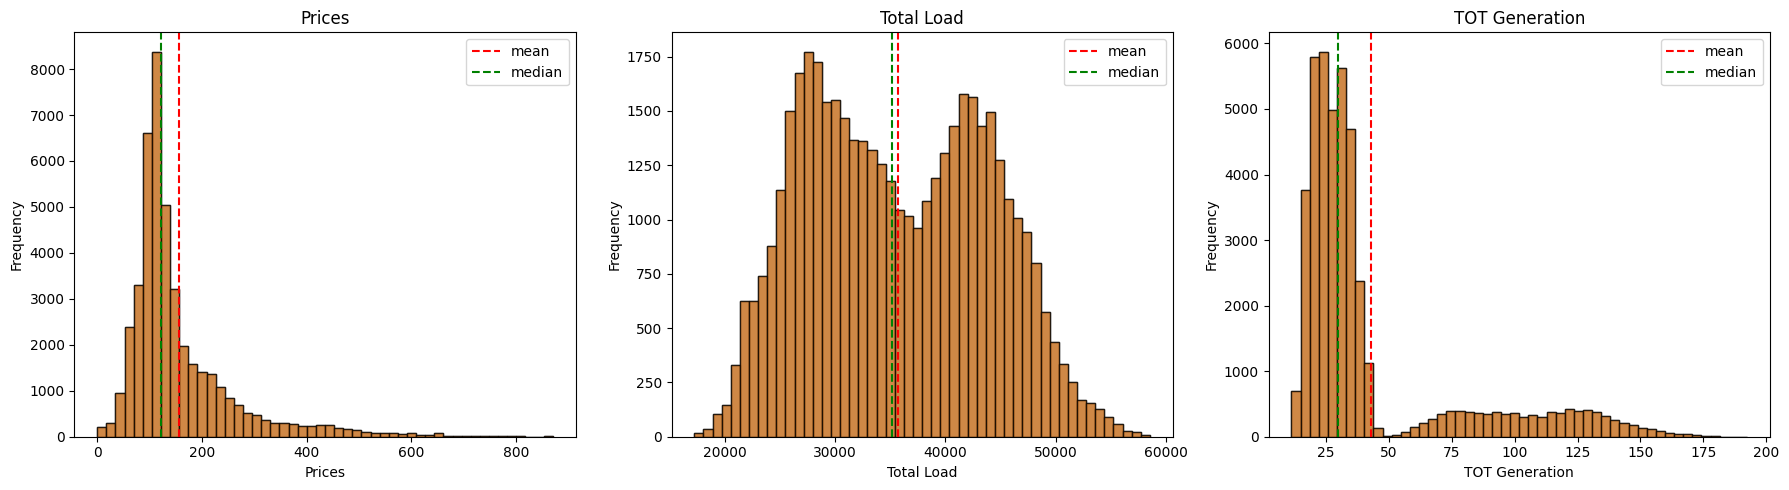

In [39]:
import matplotlib.pyplot as plt

cols = ['Prices', 'Total Load', 'TOT Generation']

fig, axes = plt.subplots(1, len(cols), figsize=(18, 5))

for i, col in enumerate(cols):
    axes[i].hist(data[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

    axes[i].hist(data[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}')

    axes[i].axvline(data[col].mean(), color='red', linestyle='--', label='mean')
    axes[i].axvline(data[col].median(), color='green', linestyle='--', label='median')

    axes[i].legend()

plt.tight_layout()
plt.show()

### 4.3. Time series analysis

#### 4.3.1. Raw time series visualization

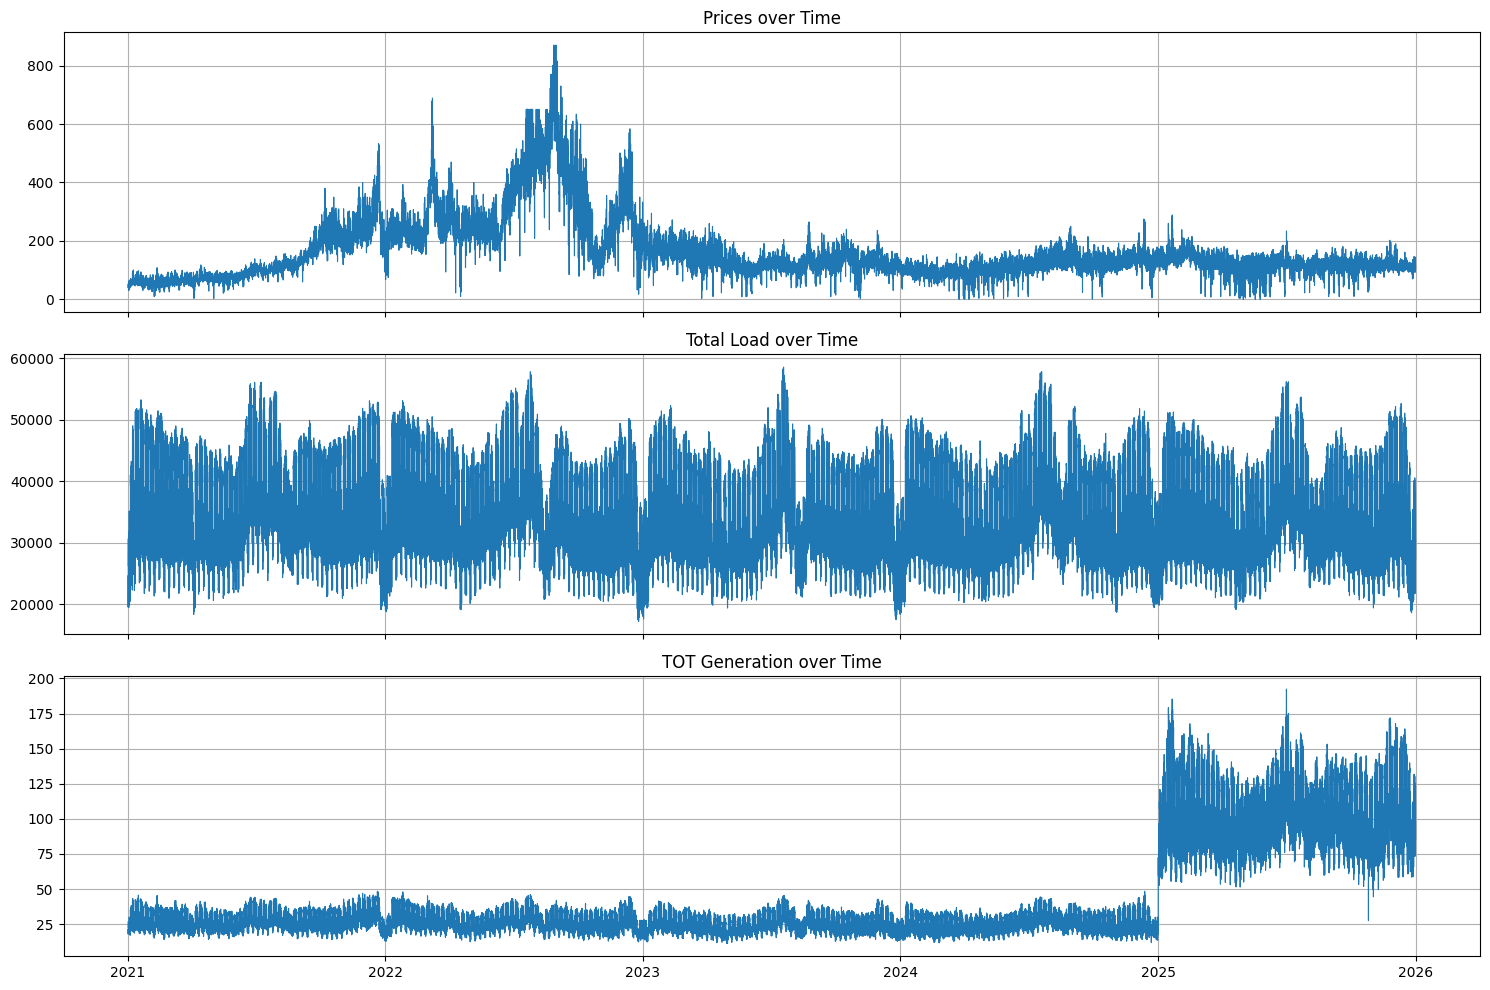

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

cols = ['Prices', 'Total Load', 'TOT Generation']

for i, col in enumerate(cols):
    ax[i].plot(data['Date'], data[col], linewidth=0.8)
    ax[i].set_title(f'{col} over Time')
    ax[i].grid(True)

plt.tight_layout()
plt.show()

#### 4.3.2. Rolling statistics 

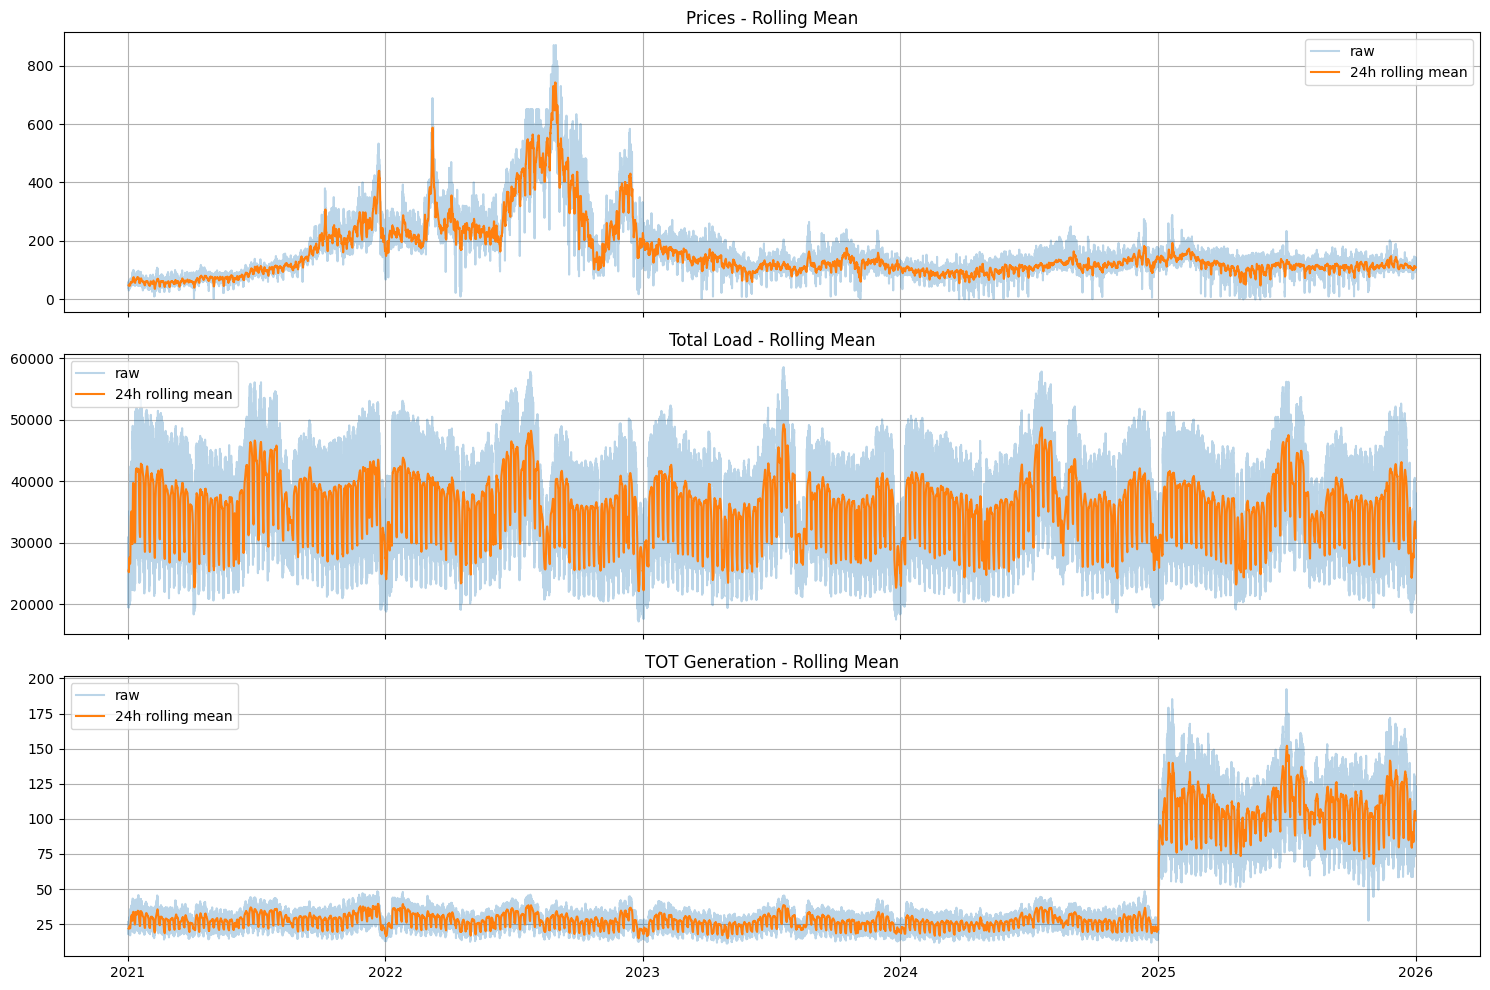

In [ ]:
window = 24  # 24h rolling window (1 day)

fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(cols):
    ax[i].plot(data['Date'], data[col], alpha=0.3, label='raw')
    ax[i].plot(data['Date'], data[col].rolling(window).mean(), label='24h rolling mean')
    ax[i].set_title(f'{col} - Rolling Mean')
    ax[i].legend()
    ax[i].grid(True)

plt.tight_layout()
plt.show()

#### 4.3.3. Volatility Analysis
Rolling stadard deviation

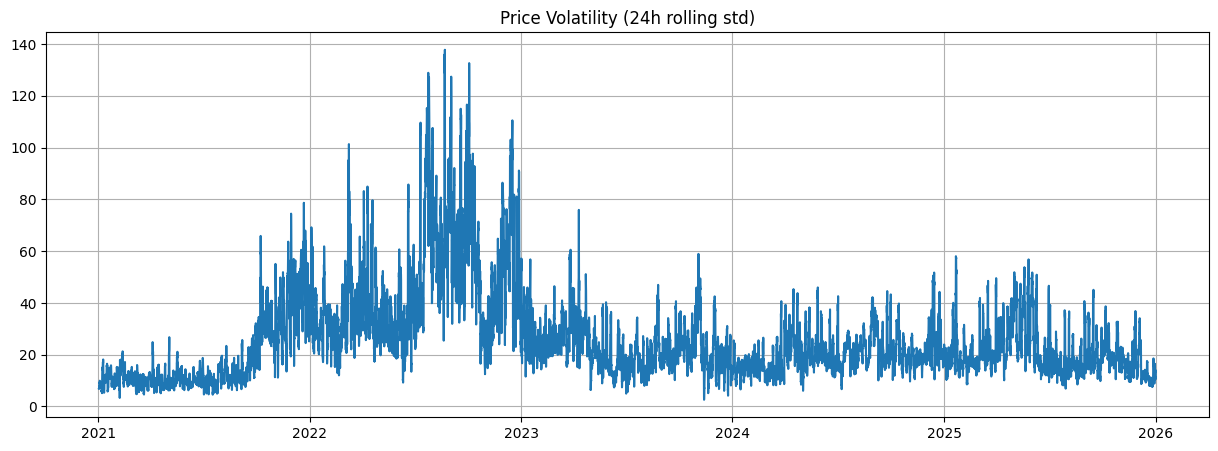

In [43]:
window = 24

data['price_volatility'] = data['Prices'].rolling(window).std()

plt.figure(figsize=(15,5))
plt.plot(data['Date'], data['price_volatility'])
plt.title('Price Volatility (24h rolling std)')
plt.grid(True)
plt.show()

#### 4.3.4. Seasonality preview

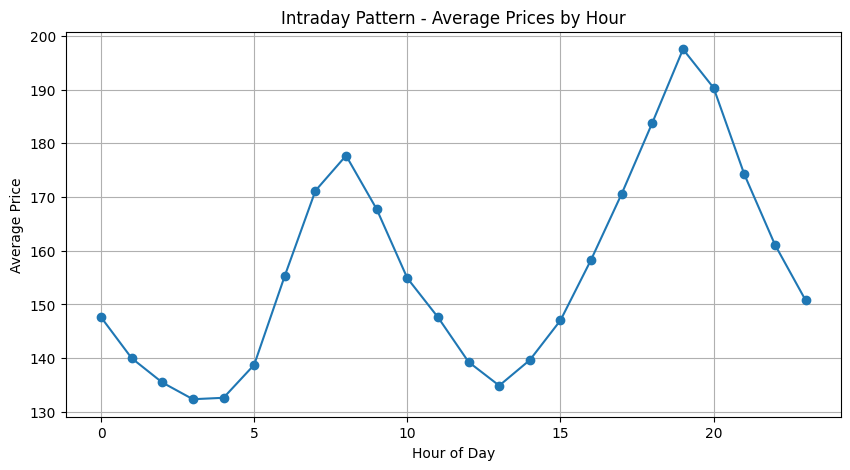

In [44]:
data['hour'] = data['Date'].dt.hour

hourly_pattern = data.groupby('hour')['Prices'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title('Intraday Pattern - Average Prices by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()

### 4.4. Relationship analysis
Supply-demand interaction

#### 4.4.1. Correlation matrix

In [ ]:
cols = [
    'Prices',
    'Total Load',
    'TOT Generation',
    'Renewables weight'
]

corr_matrix = data[cols].corr()
corr_matrix

,Prices,Total Load,TOT Generation,Renewables weight
Prices,1.000000,0.212597,-0.109767,-0.391888
Total Load,0.212597,1.000000,0.294154,0.009424
TOT Generation,-0.109767,0.294154,1.000000,0.125527
Renewables weight,-0.391888,0.009424,0.125527,1.000000


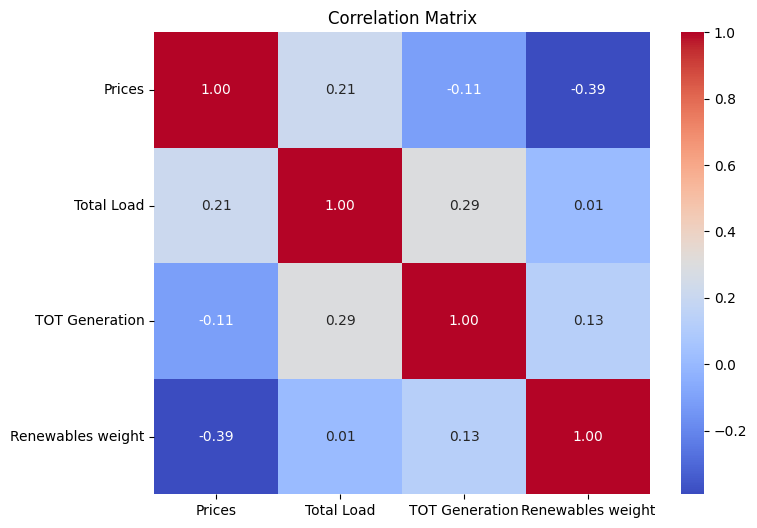

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

#### 4.4.2. Scatterplots (Prices vs Load / Generation)

##### Prices vs Load

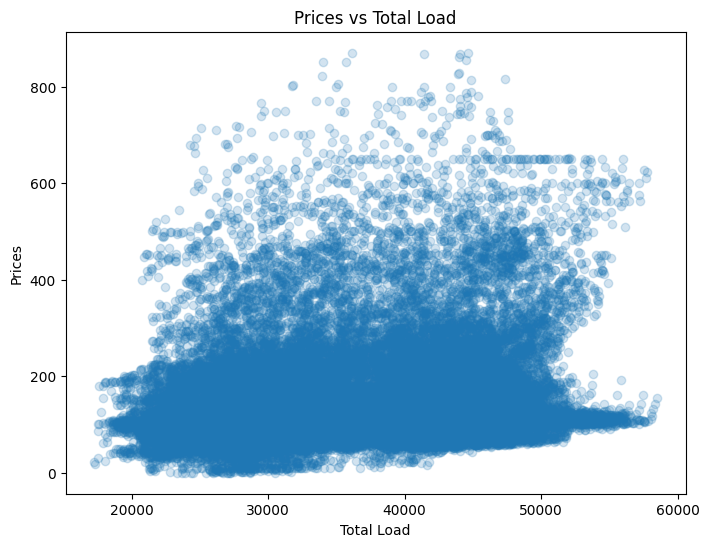

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    data['Total Load'],
    data['Prices'],
    alpha=0.2
)

plt.xlabel('Total Load')
plt.ylabel('Prices')
plt.title('Prices vs Total Load')

plt.show()

##### Price vs Generation

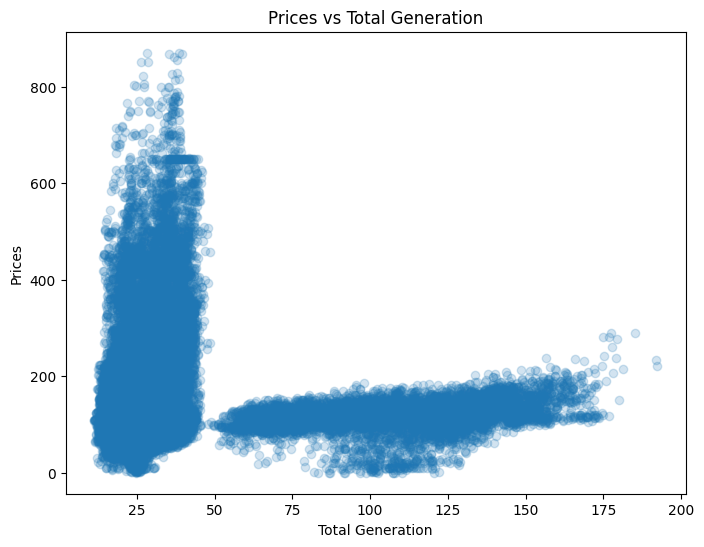

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    data['TOT Generation'],
    data['Prices'],
    alpha=0.2
)

plt.xlabel('Total Generation')
plt.ylabel('Prices')
plt.title('Prices vs Total Generation')

plt.show()

#### 4.4.3. Time lag analysis

In [ ]:
data['Load_lag_1h'] = data['Total Load'].shift(1)

data[['Prices', 'Load_lag_1h']].corr()

,Prices,Load_lag_1h
Prices,1.000000,0.197893
Load_lag_1h,0.197893,1.000000


#### 4.4.4. Preliminary economic interpretation